<a href="https://colab.research.google.com/github/saharkaddour/deep-learning-labs/blob/main/H2_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import urllib.request
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dropout, Flatten, BatchNormalization
from keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from keras.models import load_model

In [ ]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 94s 1us/step


In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.2, random_state=0)

In [ ]:
print('Train Images Shape: ', X_train.shape)
print('Train Labels Shape: ', y_train.shape)
print('\nValidation Images Shape: ', X_valid.shape)
print('Validation Labels Shape: ', y_valid.shape)
print('\nTest Images Shape: ', X_test.shape)
print('Test Labels Shape: ', y_test.shape)

Train Images Shape:  (40000, 32, 32, 3)
Train Labels Shape:  (40000, 1)

Validation Images Shape:  (10000, 32, 32, 3)
Validation Labels Shape:  (10000, 1)

Test Images Shape:  (10000, 32, 32, 3)
Test Labels Shape:  (10000, 1)


In [ ]:
# CIFAR-10 classes
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

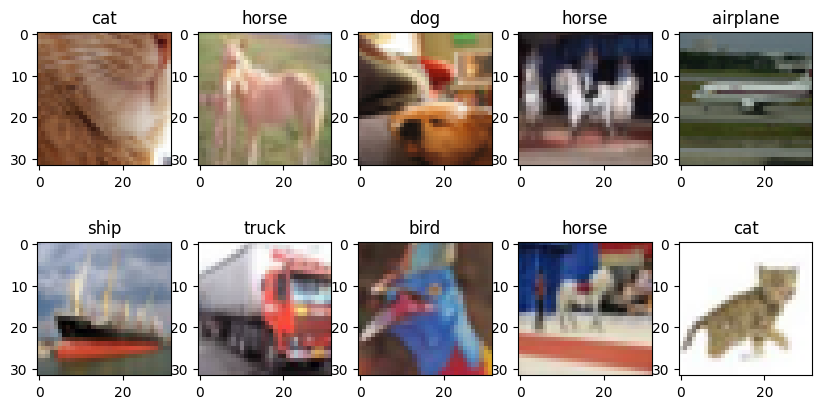

In [ ]:
# Create a new figure
plt.figure(figsize=(10,5))

# Loop over the first 25 images
for i in range(10):
    # Plot one image
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])

plt.show()

In [ ]:
# data augmentation
data_generator = ImageDataGenerator(
    # Rotate images randomly by up to 15 degrees
    rotation_range=15,
    # Randomly flip images horizontally
     horizontal_flip=True,
    # Change brightness by up to 10%
     brightness_range=[0.9, 1.1],
    #rescale
     rescale=1./255
)

In [ ]:
data_generator.fit(X_train)

In [ ]:
from tensorflow.keras.layers import Dense, Flatten
model = tf.keras.models.Sequential()
# Flatten
model.add(Flatten(input_shape=(32,32,3)))
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

In [ ]:
# Compile the model with the appropriate loss function and with sgd optimizer

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    metrics=["accuracy"]
)

In [ ]:
#train your model.
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

es = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3
)

history = model.fit(data_generator.flow(X_train, y_train, batch_size=32)
                    , epochs=30
                    , validation_data=(X_valid, y_valid), callbacks=[es, lr])

Epoch 1/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 43s 34ms/step - accuracy: 0.2599 - loss: 2.0293 - val_accuracy: 0.3627 - val_loss: 160.5965 - learning_rate: 0.0100
Epoch 2/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 42s 34ms/step - accuracy: 0.3679 - loss: 1.7904 - val_accuracy: 0.3892 - val_loss: 156.6034 - learning_rate: 0.0100
Epoch 3/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 59s 47ms/step - accuracy: 0.3884 - loss: 1.7192 - val_accuracy: 0.3785 - val_loss: 189.3693 - learning_rate: 0.0100
Epoch 4/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 65s 34ms/step - accuracy: 0.4071 - loss: 1.6760 - val_accuracy: 0.3892 - val_loss: 179.1035 - learning_rate: 0.0100
Epoch 5/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 42s 34ms/step - accuracy: 0.4263 - loss: 1.6247 - val_accuracy: 0.4237 - val_loss: 173.6266 - learning_rate: 0.0100
Epoch 6/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 42s 33ms/step - accuracy: 0.4429 - loss: 1.5851 - val_accuracy: 0.4399 - val_loss: 165.1102 - learning_rate: 0.0050
Epoch 7/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 42s 34ms/s

In [ ]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 394,636 (1.51 MB)

 Trainable params: 394,634 (1.51 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

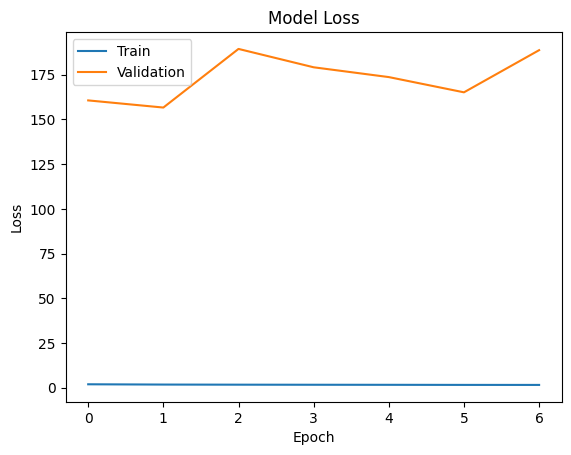

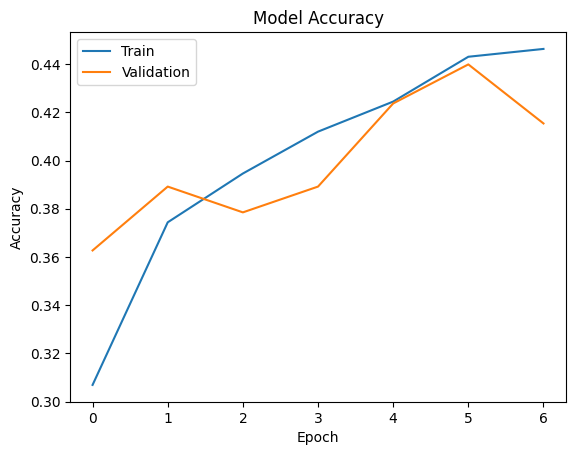

In [ ]:
# Display loss and accuracy curves
import matplotlib.pyplot as plt

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


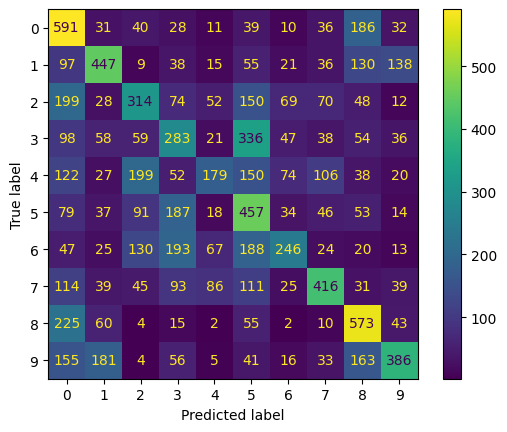

In [ ]:
# Plot the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# prédictions
y_pred = model.predict(X_valid)
y_pred_classes = np.argmax(y_pred, axis=1)

# matrice
cm = confusion_matrix(y_valid, y_pred_classes)

# affichage
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [ ]:
# Save the model
model.save("model_cifar10.h5")

from tensorflow.keras.models import load_model

model = load_model("model_cifar10.h5")